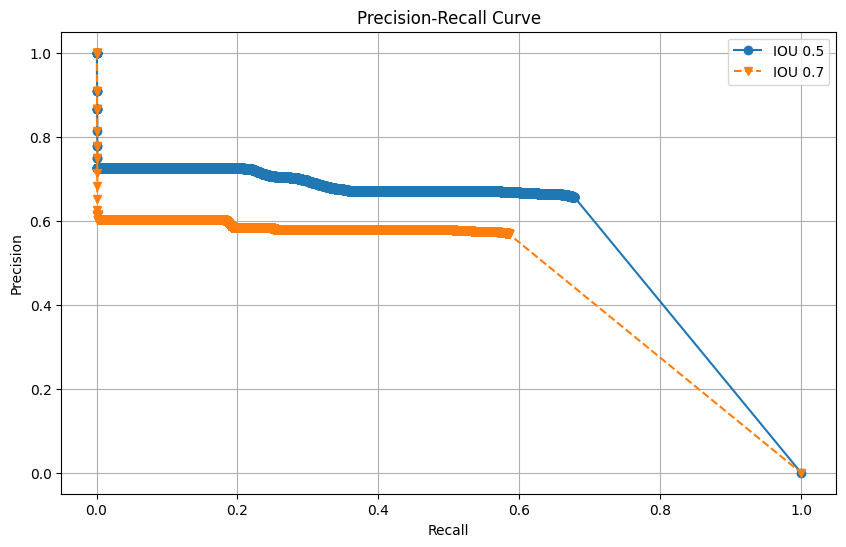

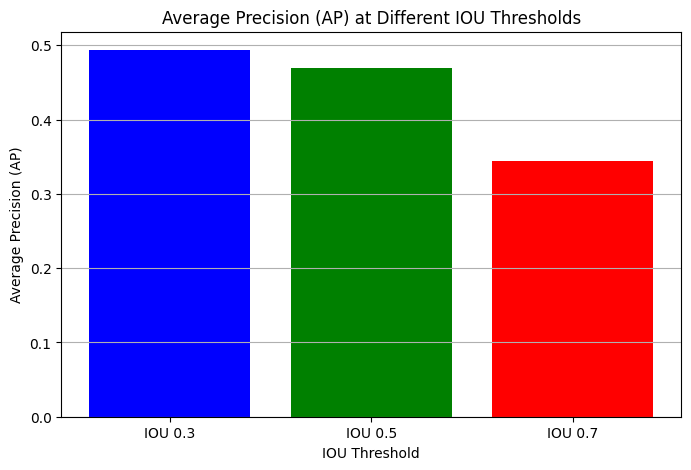

In [2]:
import yaml
import matplotlib.pyplot as plt

def visualize_evaluation_results(yaml_file_path):
    """
    Visualizes evaluation results stored in a YAML file.

    Parameters
    ----------
    yaml_file_path: str
        Path to the YAML file containing AP, recall, and precision data.
    """
    # Step 1: Load the YAML file
    with open(yaml_file_path, 'r') as file:
        results = yaml.safe_load(file)

    # Step 2: Extract data
    ap_30 = results.get('ap_30', 0)
    ap_50 = results.get('ap_50', 0)
    ap_70 = results.get('ap_70', 0)

    mrec_50 = results.get('mrec_50', [])
    mprec_50 = results.get('mpre_50', [])
    mrec_70 = results.get('mrec_70', [])
    mprec_70 = results.get('mpre_70', [])

    # Step 3: Plot Precision-Recall Curve for IOU 0.5
    plt.figure(figsize=(10, 6))
    plt.plot(mrec_50, mprec_50, label='IOU 0.5', linestyle='-', marker='o')
    plt.plot(mrec_70, mprec_70, label='IOU 0.7', linestyle='--', marker='v')

    # Step 4: Add labels and legend
    plt.title('Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.grid(True)
    plt.legend()
    plt.savefig('precision_recall_curve.png')  # Save as an image
    plt.show()

    # Step 5: Plot Average Precision
    iou_thresholds = ['IOU 0.3', 'IOU 0.5', 'IOU 0.7']
    ap_values = [ap_30, ap_50, ap_70]

    plt.figure(figsize=(8, 5))
    plt.bar(iou_thresholds, ap_values, color=['blue', 'green', 'red'])
    plt.title('Average Precision (AP) at Different IOU Thresholds')
    plt.ylabel('Average Precision (AP)')
    plt.xlabel('IOU Threshold')
    plt.grid(axis='y')
    plt.savefig('average_precision.png')  # Save as an image
    plt.show()


# Path to your YAML file
yaml_file = '/home/ws-ids-es3-01/PycharmProjects/hamdard_bm2cp/opencood/logs/adver_city_bm2cp_radar_camera_2000_00_00_00_00_00/eval_epochNone.yaml'  # Replace with your YAML file location
visualize_evaluation_results(yaml_file)